In [1]:
import numpy as np
import qutip as qt
from scipy.integrate import quad
from scipy.linalg import sqrtm
from scipy.optimize import basinhopping
from scipy.optimize import minimize

# Plotting setup
import matplotlib.pyplot as plt
plt.style.use('SciencePlots-APS.mplstyle')

## Reduced density matrix

This model based on the paper from Phys. Rev. B 78, 224413 (2008) "Quantum discord and quantum phase transition in spin chains".

In [2]:
#======================================#
# Construct the reduced density matrix
#======================================#
def omega_phi(lam, phi):
    """
    Energy spectrum of the transverse Ising chain.
    """
    omega_val = np.sqrt((lam * np.sin(phi))**2 + (1. + lam*np.cos(phi))**2 )
    return omega_val

def G_k(lam, k):
    """
    Fourier transform of the spin-spin correlation function.
    """
    # Define the integrand functions
    integrand_1 = lambda phi, k, lam: np.cos(phi * k) * (1. + lam * np.cos(phi)) / omega_phi(lam, phi)
    integrand_2 = lambda phi, k, lam: np.sin(phi * k) * np.sin(phi) * lam / omega_phi(lam, phi)
    # Compute the integrals
    integral_1, _ = quad(integrand_1, 0., np.pi, args=(k, lam))
    integral_2, _ = quad(integrand_2, 0., np.pi, args=(k, lam))
    # Calculate the Fourier transform G(k)
    G_k_val = 1. / np.pi * integral_1 - 1. / np.pi * integral_2 
    return G_k_val

# The magnetization of the spin-1/2 Ising chain
def magnetization(lam):
    """
    Compute the magnetization of the spin-1/2 Ising chain.
    """
    # Define the integrand function
    integrand = lambda phi, lam: (1. + lam * np.cos(phi)) / omega_phi(lam, phi)
    # Compute the integral
    integral, _ = quad(integrand, 0., np.pi, args=(lam,))
    # Calculate the magnetization
    magnetization_val = (-1. / np.pi) * integral
    return magnetization_val

#==============================================#
# For the nearest-neighbor correlation function
#==============================================#
# \langle \sigma^{x}_{i} \sigma^{x}_{i+n} \rangle
def correlation_xx(lam):
    return G_k(lam, -1)

# \langle \sigma^{y}_{i} \sigma^{y}_{i+n} \rangle
def correlation_yy(lam):
    return G_k(lam, 1)

# \langle \sigma^{z}_{i} \sigma^{z}_{i+n} \rangle
def correlation_zz(magnetization_val, lam):
    Gk_plus = G_k(lam, 1)
    Gk_minus = G_k(lam, -1)
    return magnetization_val**2 - (Gk_plus * Gk_minus)

#==============================================#
# Reduced density matrix of the Ising chain
#==============================================#
def compute_rho_ij(lam):
    # Compute the magnetization
    magnetization_val = magnetization(lam)
    # Compute the correlation functions
    corr_xx = correlation_xx(lam)
    corr_yy = correlation_yy(lam)
    corr_zz = correlation_zz(magnetization_val, lam)
    # Construct the reduced density matrix
    u_plus = 0.25 + (magnetization_val/2) + (corr_zz/4)
    u_minus = 0.25 - (magnetization_val/2) + (corr_zz/4)
    w = (1.-corr_zz)/4.
    x = (corr_xx + corr_yy)/4.
    y = (corr_xx - corr_yy)/4.

    rho_ij = np.array([
                      [u_plus, 0, 0, y],
                      [0, w, x, 0],
                      [0, x, w, 0],
                      [y, 0, 0, u_minus]
                      ])
    return rho_ij

In [3]:
# # Function to calculate omega_phi
# def omega_phi(gamma, lam, phi):
#     return np.sqrt((gamma * np.sin(phi))**2 + (lam + np.cos(phi))**2) / np.sqrt(2)

# # Function to calculate Gr
# def G_n(gamma, lam, n, T):
#     beta = 1.0 / T
#     integral1 = lambda phi: np.tanh(beta * omega_phi(gamma, lam, phi)) * np.cos(n * phi) * (lam + np.cos(phi)) / (2 * np.pi * omega_phi(gamma, lam, phi))
#     integral2 = lambda phi: np.tanh(beta * omega_phi(gamma, lam, phi)) * np.sin(n * phi) * np.sin(phi) * (-gamma) / (2 * np.pi * omega_phi(gamma, lam, phi))
#     result1 = np.trapz(integral1(np.linspace(0., np.pi, 1000)), np.linspace(0., np.pi, 1000))
#     result2 = np.trapz(integral2(np.linspace(0., np.pi, 1000)), np.linspace(0., np.pi, 1000))
#     return result1 + result2

# # \langle \sigma^{z} \rangle
# def sigma_z(gamma, lam, T):
#     beta = 1.0 / T
#     integrand = lambda phi: (lam + np.cos(phi)) * np.tanh(beta * omega_phi(gamma, lam, phi)) / (2. * np.pi * omega_phi(gamma, lam, phi))
#     sigma_z_val = -np.trapz(integrand(np.linspace(0., np.pi, 1000)), np.linspace(0., np.pi, 1000))
#     return sigma_z_val

# # \langle \sigma^{x}_{i} \sigma^{x}_{i+n} \rangle
# def sigma_xx_cor(gamma, lam, T):
#     return G_n(gamma, lam, -1, T)

# # \langle \sigma^{y}_{i} \sigma^{y}_{i+n} \rangle
# def sigma_yy_cor(gamma, lam, T):
#     return G_n(gamma, lam, 1, T)

# # \langle \sigma^{z}_{i} \sigma^{z}_{i+r} \rangle
# def sigma_zz_corr(sigma_z_val, gamma, lam, T):
#     Gr_plus = G_n(gamma, lam, 1, T)
#     Gr_min = G_n(gamma, lam, -1, T)
#     return sigma_z_val**2 - (Gr_plus * Gr_min)

# # Function the density matrix rho_ij
# def reduced_rho_ij(gamma, lam, T):
#     beta = 1.0 / T
#     sigma_z_val = sigma_z(gamma, lam, T)
#     sigma_xx = sigma_xx_cor(gamma, lam, T)
#     sigma_yy = sigma_yy_cor(gamma, lam, T)
#     sigma_zz = sigma_zz_corr(sigma_z_val, gamma, lam, T)

#     rho_ij = 0.25 * np.array([
#         [1. + 2. * sigma_z_val + sigma_zz, 0., 0., sigma_xx - sigma_yy],
#         [0., 1. - sigma_zz, sigma_xx + sigma_yy, 0.],
#         [0., sigma_xx + sigma_yy, 1. - sigma_zz, 0.],
#         [sigma_xx - sigma_yy, 0., 0., 1. - 2. * sigma_z_val + sigma_zz]
#     ])

#     return rho_ij

## Coherence

In [4]:
#======================================#
# GENERAL MODULES
#======================================#
def partial_trace(rho, idx):
    # Find the number of sites in the system
    N = int(np.log2(rho.shape[0]))
    # Convert numpy.ndarray to qutip.Qobj if necessary
    if isinstance(rho, np.ndarray):
        rho = qt.Qobj(rho, dims=[[2]*N]*2)
    # Compute the partial trace
    rho_ptrace = rho.ptrace(idx)
    return rho_ptrace.full()

### $l1$-norm of coherence

$$
Cl_{1} = \sum_{a \neq a'} \langle a | \rho |a' \rangle
$$

In [5]:
def Cl1(rho, basis):
    """
    Calculate the L1 norm of coherence for a given density matrix and basis.
    """
    l1_norm = 0.0
    n = len(basis)
    for i in range(n):
        for j in range(n):
            if i != j:
                # Compute the coherence term <a_i | rho | a_j>
                l1_norm += np.abs(basis[i].T.conj() @ rho @ basis[j]).item()
    return l1_norm

### Wigner-Yanase skew information

In [6]:
#================================#
# Define the Wigner-Yanase Skew
# Information 
#================================#
def commutator(A, B):
    '''
    Compute the commutator [A, B] = A.B - B.A
    '''
    # Convert qutip.Qobj to numpy.ndarray if necessary
    if isinstance(A, qt.Qobj):
        A = A.full()
    if isinstance(B, qt.Qobj):
        B = B.full()
    return A @ B - B @ A

def obs_wigner_yanase(alpha):
    '''
    Construct the observable V = \sigma^alpha_l \otimes \mathbb{1}_m for sites l and m.
    '''
    if alpha =='x':
        sigma_alpha = qt.sigmax()
    elif alpha == 'y':
        sigma_alpha = qt.sigmay()
    elif alpha == 'z':
        sigma_alpha = qt.sigmaz()
    else:
        raise ValueError(f"Invalid alpha = {alpha}")
    # Identity operator for the m-th site
    Id_m = qt.qeye(2)
    # Construct the observable V = \sigma^alpha_l \otimes \mathbb{1}_m
    V = qt.tensor(sigma_alpha, Id_m)
    return V

def WY_skew_info(rho, V):
    '''
    Compute the Wigner-Yanase skew information for a given observable V.
    '''
    # Convert qutip.Qobj to numpy.ndarray if necessary
    if isinstance(rho, qt.Qobj):
        rho = rho.full()
    if isinstance(V, qt.Qobj):
        V = V.full()
    # Compute the square root of the density matrix
    sqrt_rho = sqrtm(rho)
    # Compute the commutator [\sqrt{rho}, V]
    commutator_sqrt_rho_V = commutator(sqrt_rho, V)
    # Compute the skew information I(rho, V) = -0.5 Tr[rho, V]^2
    skew_info = -0.5 * np.trace(commutator_sqrt_rho_V @ commutator_sqrt_rho_V)
    return np.real(skew_info)

### Kirkwood-Dirac (KD) coherence

In [7]:
#======================================#
# Kirkwood-Dirac (KD) coherence
#======================================#
def basis(dim, idx):
    """
    Define a basis vector of a given dimension.
    """
    e = np.zeros((dim, 1), dtype=complex)
    e[idx, 0] = 1.0
    return e

def KD_basis(theta, phi):
    """
    Define the KD basis vectors.
    """
    b_plus = np.cos(theta / 2.) * basis(2, 0) + np.sin(theta / 2.) * np.exp(1.j * phi) * basis(2, 1)
    b_minus = np.sin(theta / 2.) * basis(2, 0) - np.cos(theta / 2.) * np.exp(1.j * phi) * basis(2, 1)
    return [b_plus, b_minus]

def KD_quasiprobability(rho, base_i, base_j):
    """
    Compute the KD quasiprobability for bases i and i.
    """
    proj_i = base_i @ base_i.T.conj()
    proj_j = base_j @ base_j.T.conj()
    return np.trace(proj_j @ proj_i @ rho)

def compute_KD(params, rho_A, basis_a):
    theta, phi = params
    basis_b = KD_basis(theta, phi)

    KD_table = []
    for i in range(2):
        for j in range(2):
            KD_table.append(KD_quasiprobability(rho_A, basis_a[i], basis_b[j]))
    return np.sum(np.abs(np.imag(KD_table)))

def KD_coherence(rho_A, basis_a):
    # Define the objective function for the KD coherence optimization.
    def KD_objective(params):
        return -compute_KD(params, rho_A, basis_a)
    
    # Define the initial guess for the optimization.
    theta_0 = np.pi / 2.
    phi_0 = 0.
    x0 = [theta_0, phi_0]

    # Perform the optimization.
    minimizer_kwargs = {
        "method": "L-BFGS-B",
        "bounds": [(0, np.pi), (0, 2 * np.pi)]
    }
    res = basinhopping(KD_objective, x0, minimizer_kwargs=minimizer_kwargs, niter=20)
    return -res.fun

In [8]:
# Parameters
gamma = 1.0
lambd_vals = np.linspace(0., 2., 100, endpoint=True)
T = 0.000000000001

# Calculate the reduced density matrix rho_ij for different values of lambda 
rho_ij_vals = []
for lam in lambd_vals:
    rho_ij = compute_rho_ij(lam)
    rho_ij_vals.append(rho_ij)

#====================================#
# Kirkwood-Dirac (KD) coherence
#====================================#
# Define the first basis vector 
sx = qt.sigmax()
vals, vecs = sx.eigenstates()
# Define the first basis vector into numpy.ndarray
base_a = [vec.full() for vec in vecs]

# Partial trace of the density matrix rho_i for different values of lambda
rho_A = []
for rho in rho_ij_vals:
    rho_A.append(partial_trace(rho, 0))

KD_coherence_vals = []
for rho_A_val in rho_A:
    KD_coherence_vals.append(KD_coherence(rho_A_val, base_a))

#====================================#
# l1 norm of coherence
#====================================#
l1_norm_vals = []
for rho in rho_A:
    l1_norm_vals.append(Cl1(rho, base_a))

#====================================#
# Wigner-Yanase skew information
#====================================#
# Define the observable V = \sigma^x_l \otimes \mathbb{1}_m
V = obs_wigner_yanase('x')

WY_skew_info_vals = []
for rho in rho_ij_vals:
    WY_skew_info_vals.append(WY_skew_info(rho, V))

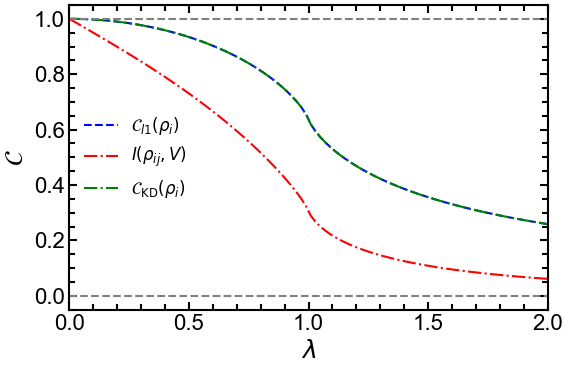

In [9]:
# Plot the results
fig = plt.figure(figsize=(6, 4))

# Plot the l1 norm of coherence
plt.plot(lambd_vals, l1_norm_vals, 'b--', label=r'$\mathcal{C}_{l1}(\rho_{i})$')
# Plot the Wigner-Yanase skew information
plt.plot(lambd_vals, WY_skew_info_vals, 'r-.', label=r'$I(\rho_{ij}, V)$')
# Plot the Kirkwood-Dirac coherence
plt.plot(lambd_vals, KD_coherence_vals, 'g-.', label=r'$\mathcal{C}_{\text{KD}}(\rho_{i})$')

# X-axis
plt.xlabel(r'$\lambda$')
plt.xlim(lambd_vals[0], lambd_vals[-1])
# Y-axis
plt.ylabel(r'$\mathcal{C}$')
plt.axhline(y=0, color='gray', linestyle='--')
plt.axhline(y=1, color='gray', linestyle='--')


plt.legend()
plt.tight_layout()
plt.show()